# XGBOOST

Mean Squared Error (MSE): 4568260.5
R-squared (R2): 0.7727997899055481


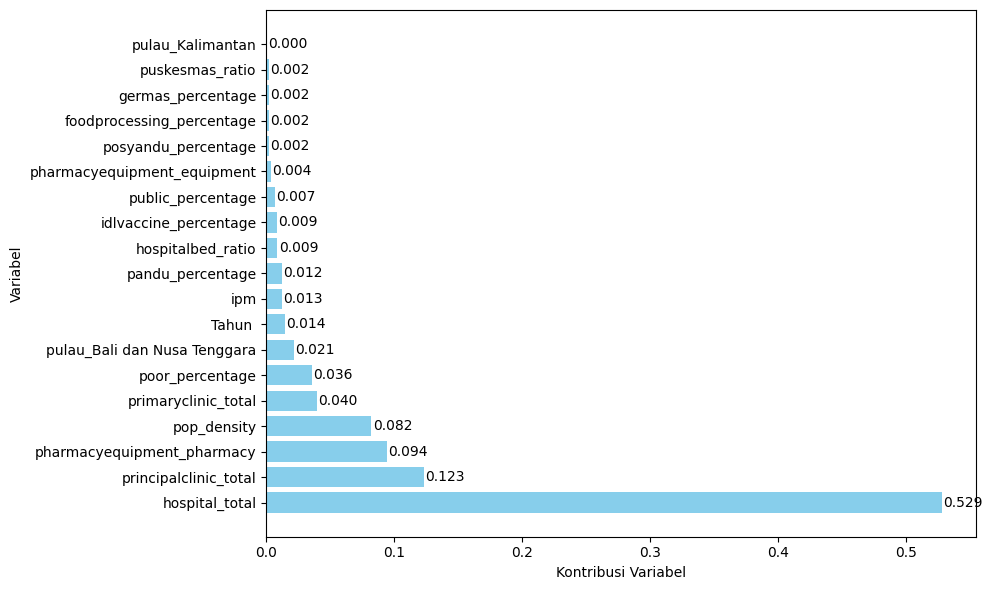

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt  # Import Matplotlib untuk plotting

# Load dataset
data = pd.read_excel('DBD_Indonesia.xlsx')

# Drop kolom yang tidak diperlukan
data = data.drop(columns=['dbd_fatalrate', 'dbd_incidencerate', 'dbd_deathtotal','Provinsi'])

# Pastikan tidak ada missing values
data = data.dropna()

# Pisahkan fitur dan target
X = data.drop(columns=['dbd_casetotal'])
y = data['dbd_casetotal']

# One-hot encoding untuk fitur kategorikal
categorical_features = X.select_dtypes(include=['object']).columns.tolist()  # Identifikasi kolom kategorikal
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # Inisialisasi encoder
encoded_data = encoder.fit_transform(X[categorical_features])  # Transformasi data kategorikal
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_features))  # DataFrame hasil encoding
X = X.drop(columns=categorical_features)  # Hapus kolom asli
X = pd.concat([X, encoded_df], axis=1)  # Gabungkan data numerik dengan hasil encoding

# Split data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inisialisasi model XGBoost
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Prediksi pada data uji
y_pred = model.predict(X_test)

# Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")


# Get feature importances
feature_importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for easier sorting
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})

importance_df = importance_df[importance_df['importance'] > 0]

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='importance', ascending=True)

# Extract sorted features and importances
sorted_features = importance_df['feature']
sorted_importances = importance_df['importance']

plt.figure(figsize=(10, 6))
bars = plt.barh(sorted_features, sorted_importances, color="skyblue")
plt.xlabel("Kontribusi Variabel")
plt.ylabel("Variabel")
plt.gca().invert_yaxis()  # fitur paling penting di atas

# Tambah angka nilai di atas batang
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', va='center')

plt.tight_layout()
plt.show()

MSE: 3859194.25
R-squared: 0.808064877986908

Fitur dengan kontribusi tertinggi dari XGBoost:
                         feature  importance
15                hospital_total    0.620365
14           primaryclinic_total    0.069493
13         principalclinic_total    0.066857
3                    pop_density    0.052151
17  pulau_Bali dan Nusa Tenggara    0.043175
2                poor_percentage    0.033292
10    pharmacyequipment_pharmacy    0.032026
0                         Tahun     0.018925
7               pandu_percentage    0.011651
16             hospitalbed_ratio    0.010206
1                            ipm    0.008094
12               puskesmas_ratio    0.006203
6              public_percentage    0.005079
21                pulau_Sulawesi    0.004928
4              germas_percentage    0.004088
19              pulau_Kalimantan    0.003882
11   pharmacyequipment_equipment    0.003730
5      foodprocessing_percentage    0.001753
9            posyandu_percentage    0.001731
8     

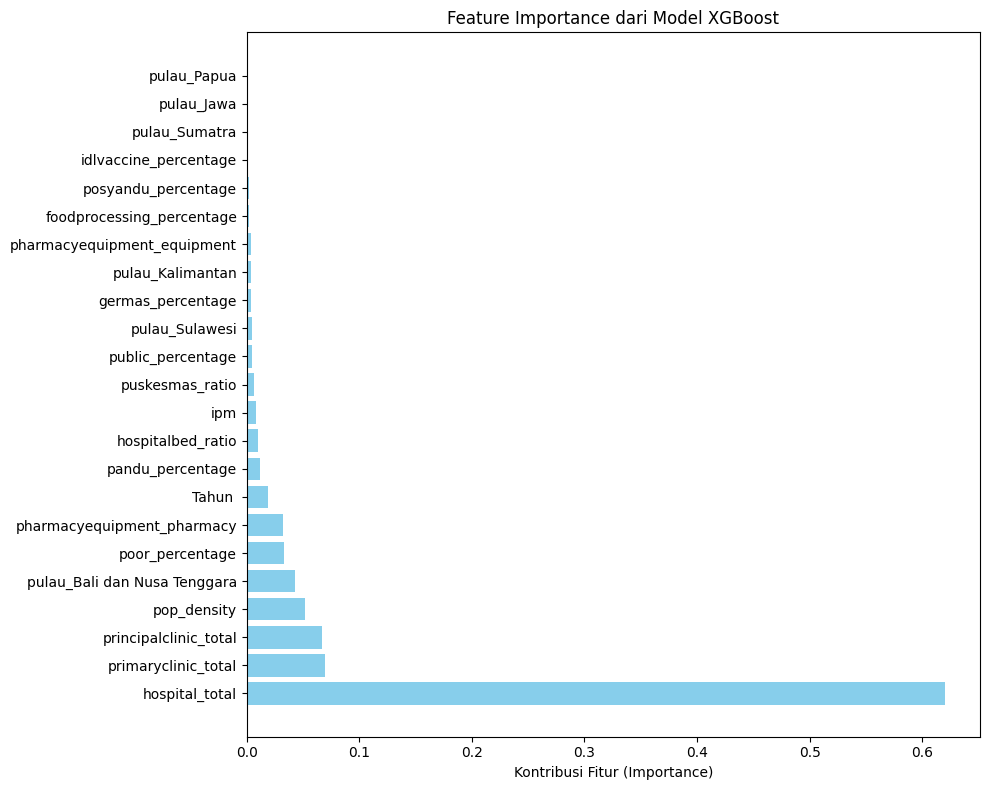

In [ ]:
from xgboost import XGBRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score

# Load dan preprocessing
data = pd.read_excel('DBD_Indonesia.xlsx')
data = data.drop(columns=['dbd_fatalrate', 'dbd_incidencerate', 'dbd_deathtotal', 'Provinsi'])
data = data.dropna()

# Target dan fitur
X = data.drop(columns=['dbd_casetotal'])
y = data['dbd_casetotal']

# One-hot encoding
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(X[categorical_features])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_features))
X = X.drop(columns=categorical_features)
X = pd.concat([X.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = XGBRegressor(n_estimators=250, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Evaluasi
y_pred = model.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"R-squared: {r2_score(y_test, y_pred)}")

# Feature importance
importances = model.feature_importances_
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Tampilkan fitur penting
print("\nFitur dengan kontribusi tertinggi dari XGBoost:")
print(importance_df)

# Sort fitur berdasarkan importance dari yang tertinggi
importance_df_sorted = importance_df.sort_values(by='importance', ascending=False)

# Plot horizontal bar chart
plt.figure(figsize=(10, 8))
plt.barh(importance_df_sorted['feature'], importance_df_sorted['importance'], color='skyblue')
plt.xlabel('Kontribusi Fitur (Importance)')
plt.title('Feature Importance dari Model XGBoost')
plt.tight_layout()
plt.show()



MSE: 3859194.25
R-squared: 0.808064877986908


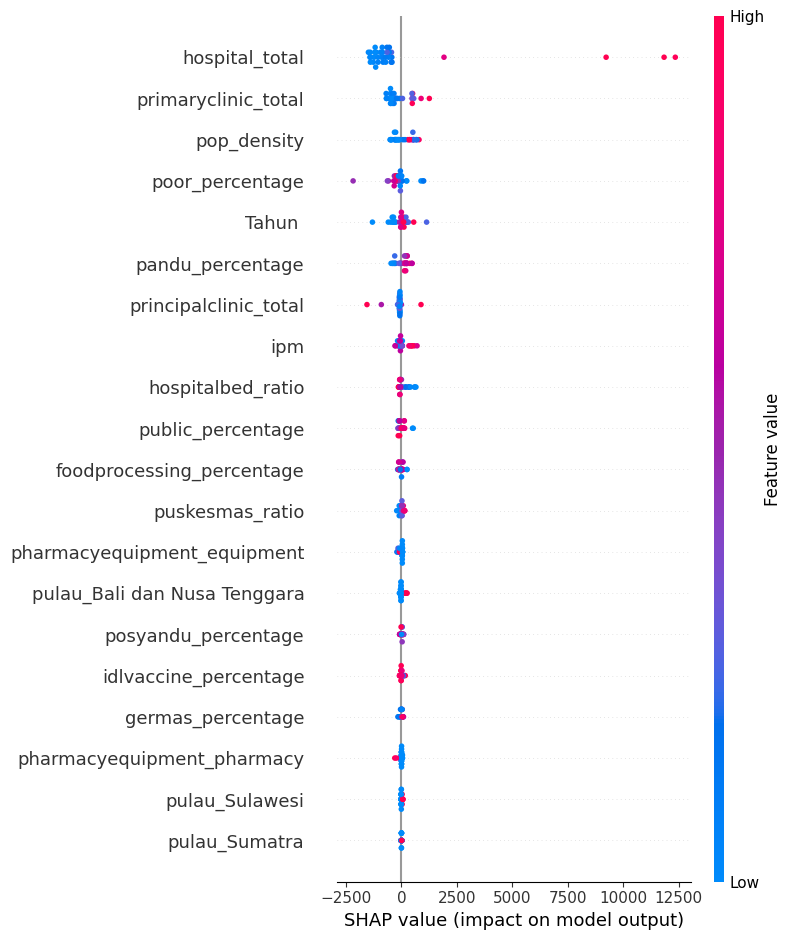

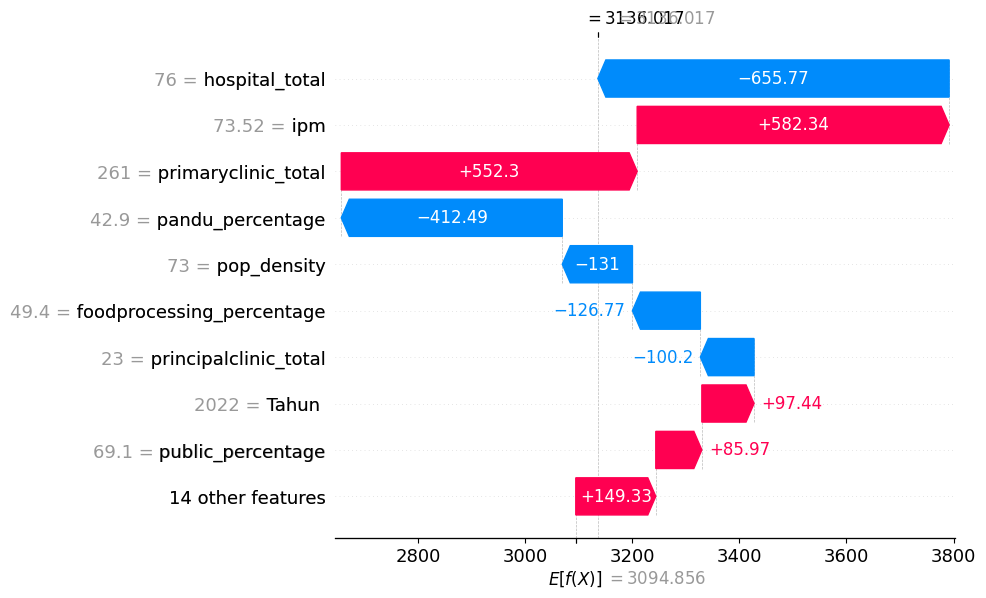

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
import shap  # library interpretasi model XGBoost

# Load dan preprocessing data (sesuai kode kamu sebelumnya)
data = pd.read_excel('DBD_Indonesia.xlsx')
data = data.drop(columns=['dbd_fatalrate', 'dbd_incidencerate', 'dbd_deathtotal', 'Provinsi'])
data = data.dropna()

X = data.drop(columns=['dbd_casetotal'])
y = data['dbd_casetotal']

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(X[categorical_features])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_features))
X = X.drop(columns=categorical_features)
X = pd.concat([X.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model XGBoost
model = XGBRegressor(n_estimators=250, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"R-squared: {r2_score(y_test, y_pred)}")

# Interpretasi dengan SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Plot global feature importance SHAP (non-linear, interaksi)
shap.summary_plot(shap_values, X_test)

# Contoh: interpretasi SHAP untuk satu data uji (instance)
shap.plots.waterfall(shap_values[0])


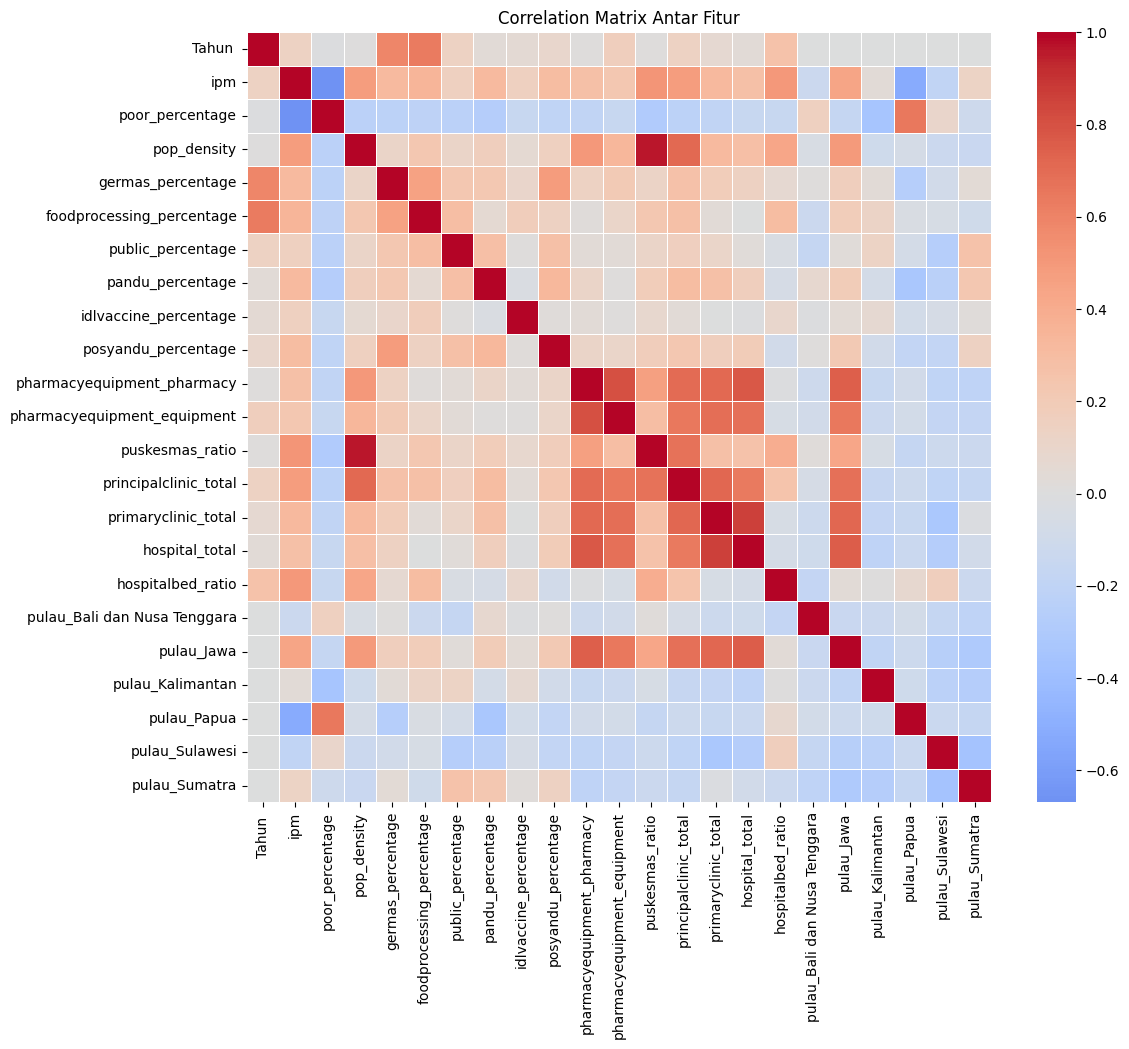

In [ ]:
import seaborn as sns

# Karena sudah one-hot encoding, semua fitur di X sekarang numerik
# Hitung correlation matrix
corr_matrix = X.corr()

# Visualisasi correlation matrix dengan heatmap seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Antar Fitur')
plt.show()


dbd_casetotal                   1.000000
pharmacyequipment_pharmacy      0.770236
hospital_total                  0.769641
primaryclinic_total             0.721189
pharmacyequipment_equipment     0.703392
principalclinic_total           0.586268
pulau_Jawa                      0.547401
ipm                             0.226777
pandu_percentage                0.202582
germas_percentage               0.186669
pop_density                     0.173904
puskesmas_ratio                 0.171368
posyandu_percentage             0.135148
Tahun                           0.081083
pulau_Bali dan Nusa Tenggara    0.048119
idlvaccine_percentage           0.019438
foodprocessing_percentage      -0.001393
public_percentage              -0.021575
pulau_Sumatra                  -0.105108
pulau_Kalimantan               -0.111052
hospitalbed_ratio              -0.128642
pulau_Papua                    -0.152183
poor_percentage                -0.167708
pulau_Sulawesi                 -0.234093
Name: dbd_caseto

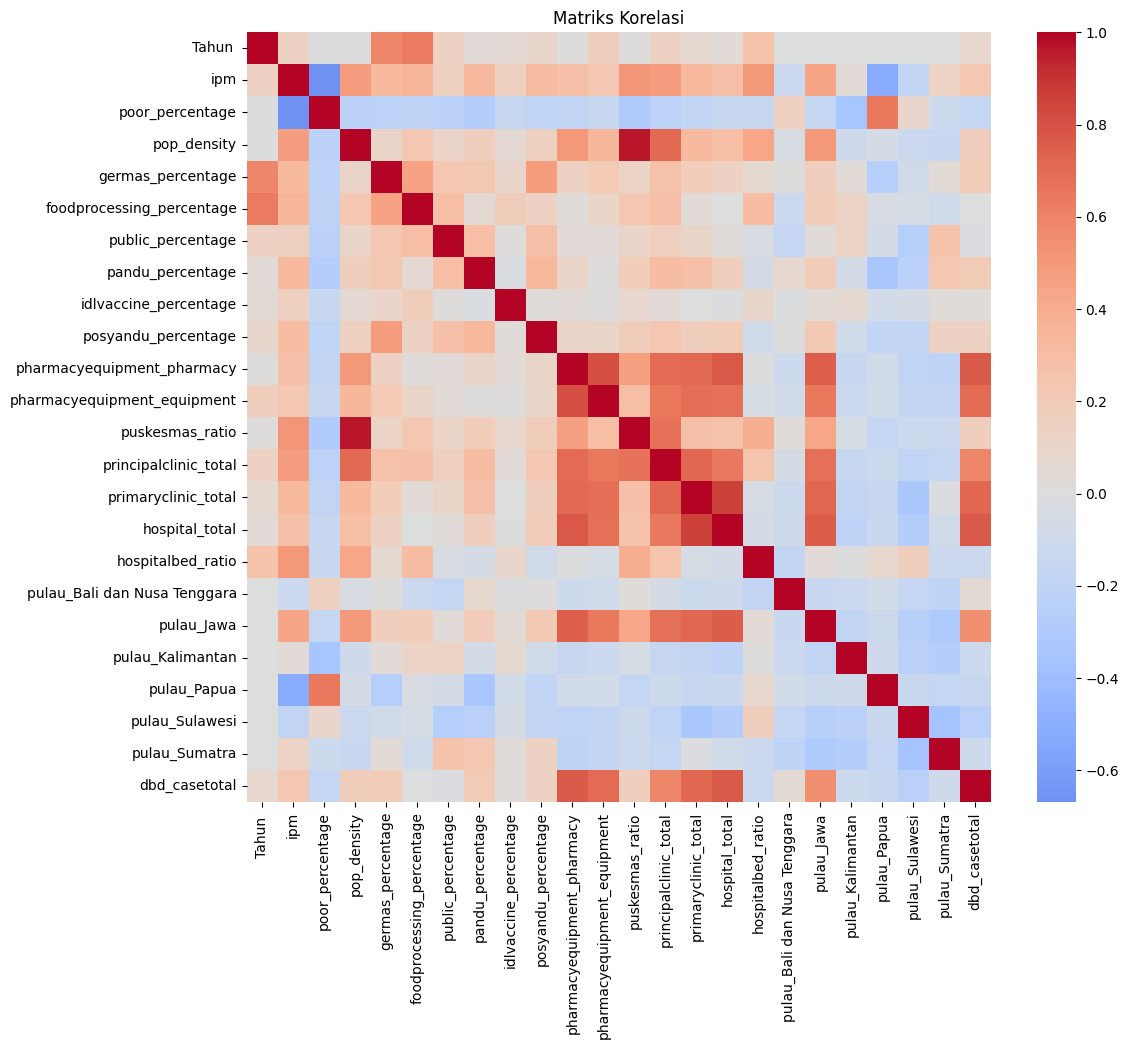

In [ ]:
import seaborn as sns

# Gabungkan fitur dan target jadi satu DataFrame untuk korelasi
data_corr = pd.concat([X, y.reset_index(drop=True)], axis=1)

# Buat matriks korelasi Pearson
corr_matrix = data_corr.corr(method='pearson')

# Tampilkan matriks korelasi (nilai angka)
print(corr_matrix['dbd_casetotal'].sort_values(ascending=False))

# Visualisasi matriks korelasi dengan heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriks Korelasi')
plt.show()


In [ ]:
# Gabungkan fitur dan target
df_corr = pd.concat([X, y.reset_index(drop=True)], axis=1)

# Hitung korelasi Pearson antara semua fitur dengan target
correlations = df_corr.corr(method='pearson')['dbd_casetotal'].drop('dbd_casetotal')

# Urutkan dari korelasi positif tertinggi ke negatif terendah
correlations_sorted = correlations.sort_values(ascending=False)

# Cetak hasil
print("Korelasi Pearson (diurutkan dari tertinggi ke terendah):")
print(correlations_sorted)


Korelasi Pearson (diurutkan dari tertinggi ke terendah):
pharmacyequipment_pharmacy      0.770236
hospital_total                  0.769641
primaryclinic_total             0.721189
pharmacyequipment_equipment     0.703392
principalclinic_total           0.586268
pulau_Jawa                      0.547401
ipm                             0.226777
pandu_percentage                0.202582
germas_percentage               0.186669
pop_density                     0.173904
puskesmas_ratio                 0.171368
posyandu_percentage             0.135148
Tahun                           0.081083
pulau_Bali dan Nusa Tenggara    0.048119
idlvaccine_percentage           0.019438
foodprocessing_percentage      -0.001393
public_percentage              -0.021575
pulau_Sumatra                  -0.105108
pulau_Kalimantan               -0.111052
hospitalbed_ratio              -0.128642
pulau_Papua                    -0.152183
poor_percentage                -0.167708
pulau_Sulawesi                 -0.234093


In [ ]:
# Ambil fitur dengan kontribusi tertinggi
top_feature = importance_df.sort_values(by='importance', ascending=False).iloc[0]['feature']
print(f"\nFitur paling dominan berdasarkan kontribusi model: {top_feature}")

# Buat data baru tanpa fitur dominan
X_dropped = X.drop(columns=[top_feature])

# Split data
X_train_drop, X_test_drop, y_train_drop, y_test_drop = train_test_split(X_dropped, y, test_size=0.2, random_state=42)

# Latih ulang model
model_drop = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
model_drop.fit(X_train_drop, y_train_drop)

# Evaluasi ulang
y_pred_drop = model_drop.predict(X_test_drop)
mse_drop = mean_squared_error(y_test_drop, y_pred_drop)
r2_drop = r2_score(y_test_drop, y_pred_drop)

print(f"\nSetelah menghapus fitur '{top_feature}':")
print(f"Mean Squared Error (MSE): {mse_drop}")
print(f"R-squared (R2): {r2_drop}")



Fitur paling dominan berdasarkan kontribusi model: hospital_total

Setelah menghapus fitur 'hospital_total':
Mean Squared Error (MSE): 14982200.0
R-squared (R2): 0.2548676133155823


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import itertools

# Load dan preprocessing data
data = pd.read_excel('DBD_Indonesia.xlsx')
data = data.drop(columns=['dbd_fatalrate', 'dbd_incidencerate', 'dbd_deathtotal', 'Provinsi'])
data = data.dropna()

X = data.drop(columns=['dbd_casetotal'])
y = data['dbd_casetotal']

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(X[categorical_features])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_features))
X = X.drop(columns=categorical_features)
X = pd.concat([X.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Parameter grid (5 nilai tiap parameter)
n_estimators_list = [50, 100, 150, 200, 250]
learning_rate_list = [0.01, 0.05, 0.1, 0.15, 0.2]
max_depth_list = [3, 4, 6, 8, 9]

results = []

# Loop semua kombinasi parameter
for n_estimators, learning_rate, max_depth in itertools.product(n_estimators_list, learning_rate_list, max_depth_list):
    model = XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'n_estimators': n_estimators,
        'learning_rate': learning_rate,
        'max_depth': max_depth,
        'MSE': mse,
        'R2': r2
    })

# Ubah ke DataFrame supaya mudah dibaca
results_df = pd.DataFrame(results)

# Tampilkan semua hasil
print("Semua kombinasi parameter dan hasil evaluasi (tanpa CV):")
print(results_df.sort_values(by='MSE').reset_index(drop=True))

# Cari parameter terbaik berdasarkan MSE
best_mse_row = results_df.loc[results_df['MSE'].idxmin()]
print("\nParameter terbaik berdasarkan MSE:")
print(best_mse_row)

# Buat model terbaik ulang dengan parameter terbaik (berdasarkan MSE)
best_model = XGBRegressor(
    n_estimators=int(best_mse_row['n_estimators']),
    learning_rate=float(best_mse_row['learning_rate']),
    max_depth=int(best_mse_row['max_depth']),
    random_state=42
)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print(f"\nEvaluasi model terbaik di test set:")
print(f"Parameter terbaik yang dipakai:")
print(f"  n_estimators: {int(best_mse_row['n_estimators'])}")
print(f"  learning_rate: {best_mse_row['learning_rate']:.3f}")
print(f"  max_depth: {int(best_mse_row['max_depth'])}")
print(f"MSE: {mean_squared_error(y_test, y_pred_best):.2f}")
print(f"R2: {r2_score(y_test, y_pred_best):.4f}")


Semua kombinasi parameter dan hasil evaluasi (tanpa CV):
     n_estimators  learning_rate  max_depth          MSE        R2
0             250           0.10          4   3859194.25  0.808065
1             200           0.10          4   3860933.50  0.807978
2             250           0.05          4   3896790.75  0.806195
3             150           0.10          4   3908493.75  0.805613
4             200           0.05          4   3932897.50  0.804399
..            ...            ...        ...          ...       ...
120            50           0.01          4  12179337.00  0.394267
121            50           0.01          3  12214892.00  0.392498
122            50           0.01          6  12404168.00  0.383085
123            50           0.01          9  12473429.00  0.379640
124            50           0.01          8  12475651.00  0.379530

[125 rows x 5 columns]

Parameter terbaik berdasarkan MSE:
n_estimators     2.500000e+02
learning_rate    1.000000e-01
max_depth        4.

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Load dan preprocessing data
data = pd.read_excel('DBD_Indonesia.xlsx')
data = data.drop(columns=['dbd_fatalrate', 'dbd_incidencerate', 'dbd_deathtotal', 'Provinsi'])
data = data.dropna()

X = data.drop(columns=['dbd_casetotal'])
y = data['dbd_casetotal']

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(X[categorical_features])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_features))
X = X.drop(columns=categorical_features)
X = pd.concat([X.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Parameter grid (5 nilai tiap parameter)
param_grid = {
    'n_estimators': [50, 100, 150, 200, 250],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth': [3, 4, 6, 8, 9]
}

model = XGBRegressor(random_state=42)

grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           scoring='neg_mean_squared_error', cv=10, verbose=1, n_jobs=-1, return_train_score=True)

grid_search.fit(X_train, y_train)

# Ambil semua hasil evaluasi
results = pd.DataFrame(grid_search.cv_results_)

# Tampilkan semua parameter dan hasil skor CV (neg MSE)
print("Semua kombinasi parameter dan hasil skor CV (neg MSE):")
print(results[['params', 'mean_test_score', 'std_test_score', 'mean_train_score', 'rank_test_score']])

# Pilih model terbaik dan evaluasi di test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\nModel terbaik:")
print(grid_search.best_params_)
print(f"Test MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Test R2: {r2_score(y_test, y_pred):.4f}")

Fitting 10 folds for each of 125 candidates, totalling 1250 fits
Semua kombinasi parameter dan hasil skor CV (neg MSE):
                                                params  mean_test_score  \
0    {'learning_rate': 0.01, 'max_depth': 3, 'n_est...    -1.556746e+07   
1    {'learning_rate': 0.01, 'max_depth': 3, 'n_est...    -1.309157e+07   
2    {'learning_rate': 0.01, 'max_depth': 3, 'n_est...    -1.179617e+07   
3    {'learning_rate': 0.01, 'max_depth': 3, 'n_est...    -1.122008e+07   
4    {'learning_rate': 0.01, 'max_depth': 3, 'n_est...    -1.029607e+07   
..                                                 ...              ...   
120  {'learning_rate': 0.2, 'max_depth': 9, 'n_esti...    -1.014436e+07   
121  {'learning_rate': 0.2, 'max_depth': 9, 'n_esti...    -1.014862e+07   
122  {'learning_rate': 0.2, 'max_depth': 9, 'n_esti...    -1.014862e+07   
123  {'learning_rate': 0.2, 'max_depth': 9, 'n_esti...    -1.014863e+07   
124  {'learning_rate': 0.2, 'max_depth': 9, 'n_esti... 

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Load dan preprocessing data
data = pd.read_excel('DBD_Indonesia.xlsx')
data = data.drop(columns=['dbd_fatalrate', 'dbd_incidencerate', 'dbd_deathtotal', 'Provinsi'])
data = data.dropna()

X = data.drop(columns=['dbd_casetotal'])
y = data['dbd_casetotal']

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(X[categorical_features])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_features))
X = X.drop(columns=categorical_features)
X = pd.concat([X.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Parameter grid (5 nilai tiap parameter)
param_grid = {
    'n_estimators': [50, 100, 150, 200, 250],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth': [3, 4, 6, 8, 9]
}

model = XGBRegressor(random_state=42)

grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           scoring='neg_mean_squared_error', cv=5, verbose=1, n_jobs=-1, return_train_score=True)

grid_search.fit(X_train, y_train)

# Ambil semua hasil evaluasi
results = pd.DataFrame(grid_search.cv_results_)

# Tampilkan semua parameter dan hasil skor CV (neg MSE)
print("Semua kombinasi parameter dan hasil skor CV (neg MSE):")
print(results[['params', 'mean_test_score', 'std_test_score', 'mean_train_score', 'rank_test_score']])

# Pilih model terbaik dan evaluasi di test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\nModel terbaik:")
print(grid_search.best_params_)
print(f"Test MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Test R2: {r2_score(y_test, y_pred):.4f}")

Fitting 5 folds for each of 125 candidates, totalling 625 fits
Semua kombinasi parameter dan hasil skor CV (neg MSE):
                                                params  mean_test_score  \
0    {'learning_rate': 0.01, 'max_depth': 3, 'n_est...    -1.447120e+07   
1    {'learning_rate': 0.01, 'max_depth': 3, 'n_est...    -1.145696e+07   
2    {'learning_rate': 0.01, 'max_depth': 3, 'n_est...    -1.007879e+07   
3    {'learning_rate': 0.01, 'max_depth': 3, 'n_est...    -9.332294e+06   
4    {'learning_rate': 0.01, 'max_depth': 3, 'n_est...    -8.858867e+06   
..                                                 ...              ...   
120  {'learning_rate': 0.2, 'max_depth': 9, 'n_esti...    -1.051445e+07   
121  {'learning_rate': 0.2, 'max_depth': 9, 'n_esti...    -1.054707e+07   
122  {'learning_rate': 0.2, 'max_depth': 9, 'n_esti...    -1.054720e+07   
123  {'learning_rate': 0.2, 'max_depth': 9, 'n_esti...    -1.054720e+07   
124  {'learning_rate': 0.2, 'max_depth': 9, 'n_esti...   

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Load dan preprocessing data
data = pd.read_excel('DBD_Indonesia.xlsx')
data = data.drop(columns=['dbd_fatalrate', 'dbd_incidencerate', 'dbd_deathtotal', 'Provinsi'])
data = data.dropna()

X = data.drop(columns=['dbd_casetotal'])
y = data['dbd_casetotal']

# One-hot encoding untuk fitur kategorikal
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(X[categorical_features])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_features))
X = X.drop(columns=categorical_features)
X = pd.concat([X.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

# Split data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Parameter grid untuk GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150, 200, 250],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth': [3, 4, 6, 8, 9]
}

model = XGBRegressor(random_state=42)

grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           scoring='neg_mean_squared_error', cv=5, verbose=1, n_jobs=-1, return_train_score=True)

grid_search.fit(X_train, y_train)

# Evaluasi model terbaik di data latih
best_model = grid_search.best_estimator_
y_train_pred = best_model.predict(X_train)

train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print("Model terbaik XGBoost:")
print(grid_search.best_params_)
print(f"Train MSE: {train_mse:.2f}")
print(f"Train R2: {train_r2:.4f}")


Fitting 5 folds for each of 125 candidates, totalling 625 fits
Model terbaik XGBoost:
{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 250}
Train MSE: 223.57
Train R2: 1.0000


Evaluasi Model Terbaik pada Data Latih:
Train MSE: 223.57
Train R²: 1.0000

Kontribusi Semua Variabel (dalam bentuk Gain Proporsional):
                         Feature  NormalizedGain
15                hospital_total    0.6203648926
14           primaryclinic_total    0.0694925572
13         principalclinic_total    0.0668565361
3                    pop_density    0.0521509452
17  pulau_Bali dan Nusa Tenggara    0.0431748186
2                poor_percentage    0.0332916288
10    pharmacyequipment_pharmacy    0.0320264947
0                         Tahun     0.0189248691
7               pandu_percentage    0.0116510078
16             hospitalbed_ratio    0.0102062900
1                            ipm    0.0080936956
12               puskesmas_ratio    0.0062028884
6              public_percentage    0.0050785397
19                pulau_Sulawesi    0.0049275399
4              germas_percentage    0.0040881183
18              pulau_Kalimantan    0.0038816170
11   pharmacyequipment_equipmen

<ipython-input-7-4bbbfa495b4f>:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(24), x='NormalizedGain', y='Feature', palette='viridis')


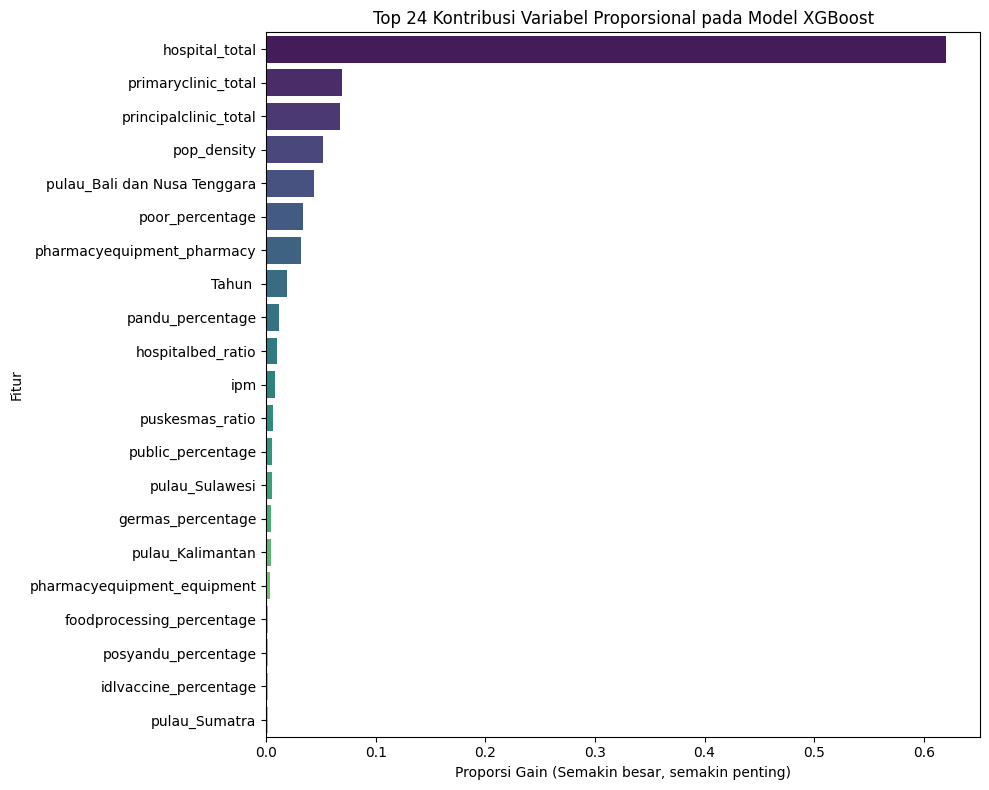

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dan preprocessing data
data = pd.read_excel('DBD_Indonesia.xlsx')
data = data.drop(columns=['dbd_fatalrate', 'dbd_incidencerate', 'dbd_deathtotal', 'Provinsi'])
data = data.dropna()

X = data.drop(columns=['dbd_casetotal'])
y = data['dbd_casetotal']

# One-hot encoding untuk fitur kategorikal
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(X[categorical_features])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_features))
X = X.drop(columns=categorical_features)
X = pd.concat([X.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

# Split data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# LATIH ULANG MODEL DENGAN PARAMETER TERBAIK
best_model = XGBRegressor(
    learning_rate=0.1,
    max_depth=4,
    n_estimators=250,
    random_state=42
)
best_model.fit(X_train, y_train)

# Evaluasi di data latih
y_train_pred = best_model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print("Evaluasi Model Terbaik pada Data Latih:")
print(f"Train MSE: {train_mse:.2f}")
print(f"Train R²: {train_r2:.4f}")

# ================================
# KONTRIBUSI VARIABEL (FEATURE IMPORTANCE - PROPORSIONAL)
# ================================
booster = best_model.get_booster()
importance_dict = booster.get_score(importance_type='gain')

# Normalisasi gain: gain / total gain
total_gain = sum(importance_dict.values())
importance_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'NormalizedGain': [gain / total_gain for gain in importance_dict.values()]
}).sort_values(by='NormalizedGain', ascending=False)

# Atur agar semua desimal terlihat
pd.set_option('display.float_format', lambda x: f'{x:.10f}')
pd.set_option('display.max_rows', None)  # Tampilkan semua baris

# Tampilkan kontribusi semua variabel (dalam bentuk proporsi)
print("\nKontribusi Semua Variabel (dalam bentuk Gain Proporsional):")
print(importance_df)

# Visualisasi top 24 fitur
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(24), x='NormalizedGain', y='Feature', palette='viridis')
plt.title('Top 24 Kontribusi Variabel Proporsional pada Model XGBoost')
plt.xlabel('Proporsi Gain (Semakin besar, semakin penting)')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()




# LSTM

In [ ]:
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 🔒 Set seed untuk hasil reproducible
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# Load dataset
data = pd.read_excel('DBD_Indonesia.xlsx')

# Drop kolom yang tidak diperlukan
data = data.drop(columns=['dbd_fatalrate', 'dbd_incidencerate', 'dbd_deathtotal', 'pulau'])

# Hapus missing values
data = data.dropna()

# Pisahkan fitur dan target
X = data.drop(columns=['dbd_casetotal'])
y = data['dbd_casetotal']

# Encoding untuk fitur kategorikal
for col in X.select_dtypes(include=['object']).columns:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col])

# Normalisasi fitur numerik
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

# Normalisasi target (opsional tapi disarankan)
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Fungsi sliding window
def create_sequences(X, y, time_steps=3):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# Buat data sekuensial
time_steps = 3
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=seed)

# Bangun model LSTM
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Callback EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# Prediksi
y_pred = model.predict(X_test)

# Balikkan scaling
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)

# Evaluasi
mse = mean_squared_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

# Plot loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Data Pelatihan')
plt.plot(history.history['val_loss'], label='Data Validasi')
plt.xlabel('Epochs')
plt.ylabel('Nilai Kerugian')
plt.legend()
plt.tight_layout()
plt.show()
